In [1]:
from argparse import Namespace
from captum.attr import IntegratedGradients
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch

import sys
import os
sys.path.append(os.path.abspath(".."))

tsa_root = os.path.abspath("../ts_survival_prediction/src")
if tsa_root not in sys.path:
    sys.path.insert(0, tsa_root)

from ts_survival_prediction.src.model.FNN import FNN
from ts_survival_prediction.src.survival.losses import CoxLoss
from ts_survival_prediction.src.utils.data_utils import obtain_dataloader
from ts_survival_prediction.src.data.survival_dataset import RNASurvivalDataset


/scratch/2370352/conda/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [121]:
def save_genes(importance_df, top_n, run_name, filepath="gene_logs.jsonl"):
    subset = importance_df.head(top_n)
    genes = subset['gene'].to_list()
    entry = {
        "run_name": run_name,
        "genes": genes
    }
    with open(filepath, "a") as f:  # append mode
        f.write(json.dumps(entry) + "\n")

In [178]:
device = 'cpu'

exp_code = 'mlp_analysis_lasso'
fold = 0

args = Namespace(
    model="mlp",
    task="dss_survival_brca",
    data_source="/scratch/2370352/my-research/data/clinical_data/brca_clinical",
    exp_code=exp_code,
    omics_type="TCGA-BRCA.star_tpm.csv",  # <- możesz zmienić dynamicznie
    data_type="csv",
    expression_data_path="/scratch/2370352/my-research/data/0_data_for_mlp_testing",
    folds=fold,
    target_col="dss_survival_days"
)

In [179]:
loss = CoxLoss()
model = FNN(20260, 'mlp', [256, 256], loss)
model.from_pretrained(f'/scratch/2370352/my-research/ts_survival_prediction/src/results/dss_survival_brca/{exp_code}/Fold_{fold}/model_checkpoint.pth', device=device)
model.eval()

FNN(
  (loss_fn): CoxLoss()
  (fc_layers): Sequential(
    (0): MLP_Block(
      (net): Sequential(
        (0): Linear(in_features=20260, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.25, inplace=False)
      )
    )
    (1): Dropout(p=0.5, inplace=False)
    (2): MLP_Block(
      (net): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.25, inplace=False)
      )
    )
    (3): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=1, bias=False)
)

In [180]:
# 1. Inicjalizacja datasetów (zakładam, że masz już obiekt `args`)
train_dataset = RNASurvivalDataset(args, 'train', 'rna', 0)
test_dataset = RNASurvivalDataset(args, 'test', 'rna', 0)

In [181]:
# 2. Przygotowanie danych "tła" (Background Data)
# SHAP używa ich do ustalenia "stanu zerowego". Bierzemy 100 próbek z treningu.
background_data_np = train_dataset.df_rna.values[:300]
background_data = torch.tensor(background_data_np, dtype=torch.float32).to(device)

In [182]:
# 3. Przygotowanie danych testowych do wyjaśnienia
# Wyciągamy wartości z DataFrame'u testowego
test_data_np = test_dataset.df_rna.values
test_data = torch.tensor(test_data_np, dtype=torch.float32).to(device)

In [183]:
# 4. Wyciągnięcie nazw genów (z nazw kolumn w DataFrame)
gene_names = test_dataset.df_rna.columns.tolist()

In [184]:
# 6. Obliczenia SHAP
print("Inicjalizacja DeepExplainer...")
original_forward = model.forward
model.forward = model.forward_no_loss
explainer = shap.DeepExplainer(model, background_data)
print("Done")

Inicjalizacja DeepExplainer...
Done


In [185]:
shap_values = explainer.shap_values(test_data)

In [186]:
# 7. Formatowanie wyników pod wykres
# PyTorch z SHAP często zwraca listę (po jednej tablicy na klasę wyjściową).
# Dla num_classes=1 interesuje nas zerowy indeks.
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0]
else:
    shap_values_to_plot = shap_values

In [187]:
# Upewniamy się, że shap_values_to_plot jest dwuwymiarowe (pacjenci x geny)
# Jeśli ma kształt (N, 1, 20000), to wyciągamy środek
if len(shap_values_to_plot.shape) == 3:
    shap_values_to_plot = shap_values_to_plot.reshape(shap_values_to_plot.shape[0], -1)

# Oblicz średnią i wymuś 1D
mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0).flatten()

# Sprawdźmy długości - muszą być identyczne!
print(f"Liczba nazw genów: {len(gene_names)}")
print(f"Liczba wartości SHAP: {len(mean_abs_shap)}")

# Stwórz tabelę
importance_df = pd.DataFrame({
    'gene': gene_names,
    'mean_abs_shap': mean_abs_shap
})

importance_df = importance_df.sort_values(by='mean_abs_shap', ascending=False)
print(importance_df.head(20))

Liczba nazw genów: 20260
Liczba wartości SHAP: 20260
                gene  mean_abs_shap
2932            FGL1       0.004258
11371         RNF183       0.003990
5327            NFE2       0.003925
20057  RP11-697E2.13       0.003735
17940          TTC34       0.003653
12695        PLA2G1B       0.003640
16731         CLEC9A       0.003608
14257         TMEM31       0.003558
10172         CCDC24       0.003549
18101        NDUFAF8       0.003531
13010           AZU1       0.003524
9362          TUBA3E       0.003470
2004        EPB41L4B       0.003409
15518         CYP4F2       0.003381
7815             AK7       0.003353
18704        C5orf17       0.003338
17959      LINC01644       0.003327
19400   CTB-50L17.14       0.003294
1723          SH3BP2       0.003277
11398          ARMC3       0.003263


Kształt SHAP values: (215, 20260)
Kształt danych testowych: (215, 20260)
Liczba nazw genów: 20260
Rysowanie wykresu...


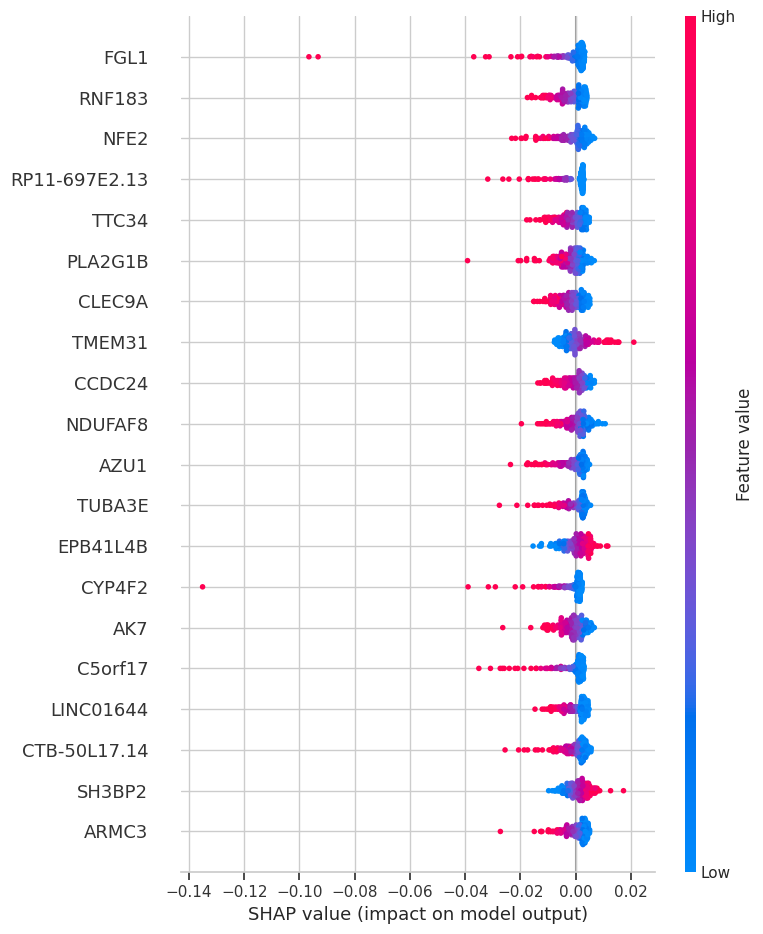

In [188]:
# 1. Konwersja nazw genów na numpy array (to rozwiązuje Twój TypeError)
gene_names_np = np.array(gene_names)

# 2. Upewnij się, że kształty się zgadzają
print(f"Kształt SHAP values: {shap_values_to_plot.shape}")
print(f"Kształt danych testowych: {test_data_np.shape}")
print(f"Liczba nazw genów: {len(gene_names_np)}")

# 3. Rysowanie wykresu
print("Rysowanie wykresu...")
shap.summary_plot(
    shap_values_to_plot, 
    test_data_np, 
    feature_names=gene_names_np, # Tutaj używamy wersji NP
    max_display=20
)

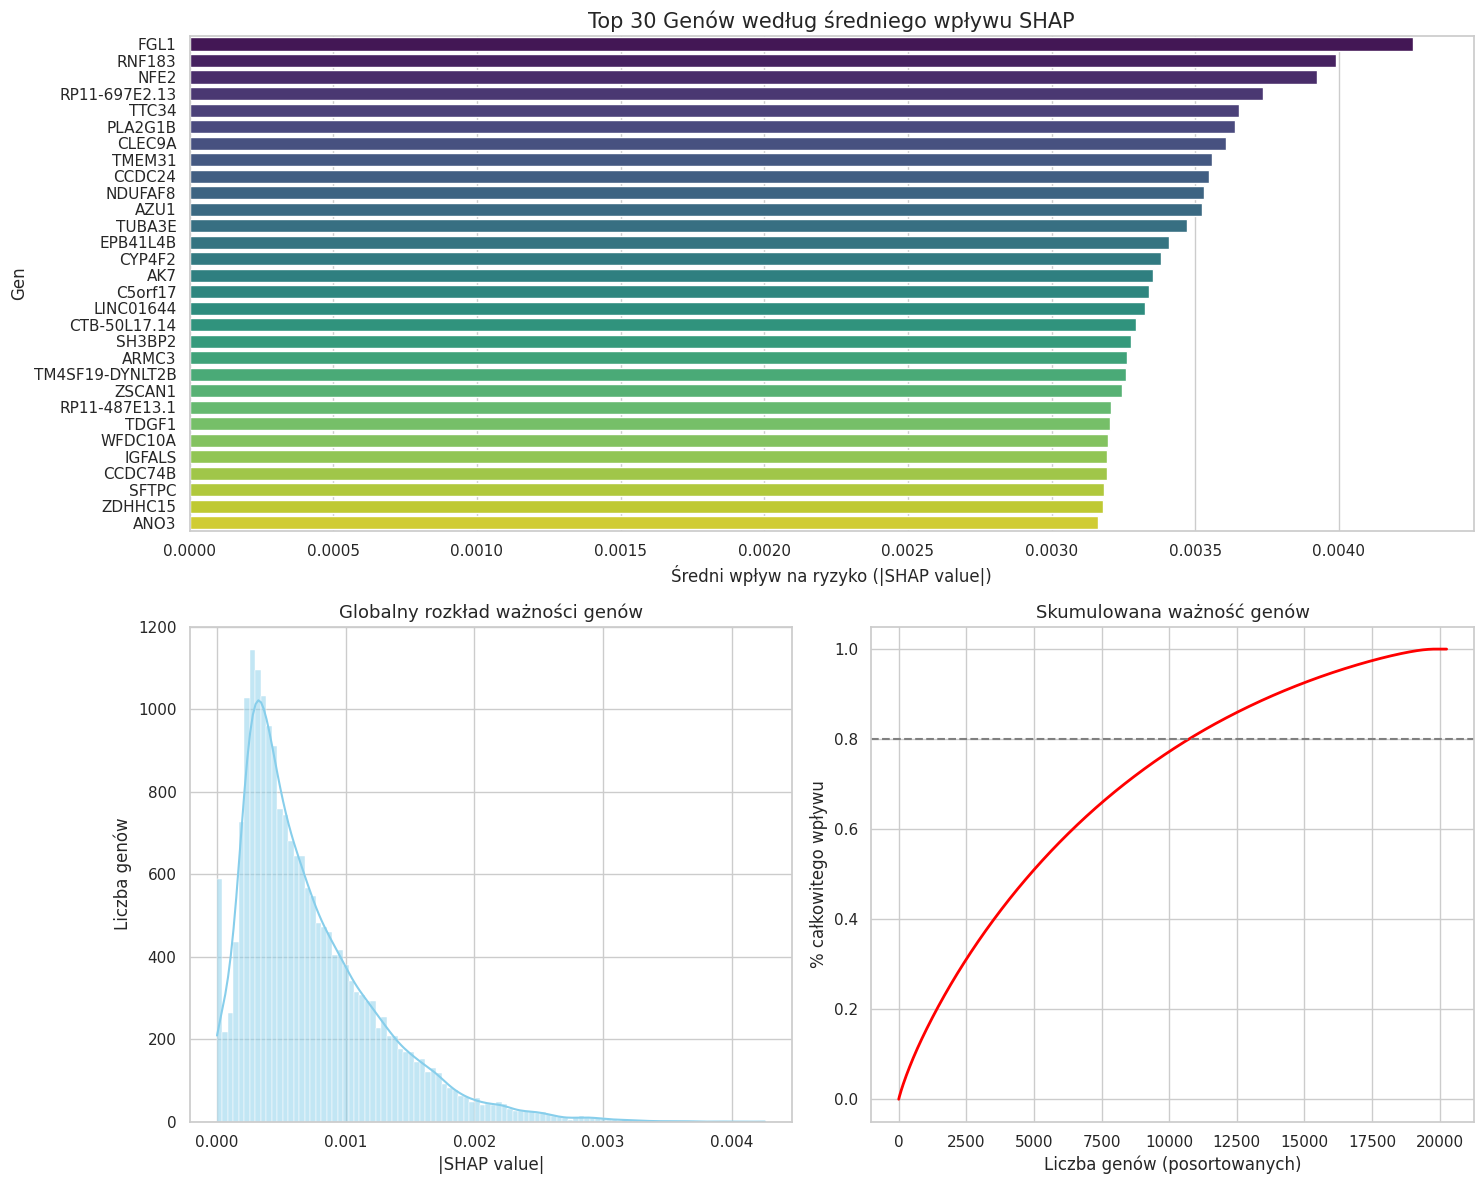

Statystyki opisowe ważności genów:
count    20260.000000
mean         0.000714
std          0.000534
min          0.000000
25%          0.000324
50%          0.000567
75%          0.000977
max          0.004258
Name: mean_abs_shap, dtype: float64


In [189]:

# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# --- 1. Top 30 najważniejszych genów ---
plt.subplot(2, 1, 1)
top_n = 30
sns.barplot(
    data=importance_df.head(top_n), 
    x='mean_abs_shap', 
    y='gene', 
    palette='viridis'
)
plt.title(f'Top {top_n} Genów według średniego wpływu SHAP', fontsize=15)
plt.xlabel('Średni wpływ na ryzyko (|SHAP value|)', fontsize=12)
plt.ylabel('Gen', fontsize=12)

# --- 2. Rozkład wszystkich wartości (Histogram) ---
plt.subplot(2, 2, 3)
sns.histplot(importance_df['mean_abs_shap'], bins=100, kde=True, color='skyblue')
# plt.yscale('log') # Skala logarytmiczna, bo większość genów będzie miała wpływ bliski 0
plt.title('Globalny rozkład ważności genów', fontsize=13)
plt.xlabel('|SHAP value|')
plt.ylabel('Liczba genów')

# --- 3. Skumulowana ważność (Zasada Pareto) ---
plt.subplot(2, 2, 4)
sorted_vals = importance_df['mean_abs_shap'].values
cumulative_importance = np.cumsum(sorted_vals) / np.sum(sorted_vals)
plt.plot(cumulative_importance, color='red', lw=2)
plt.axhline(y=0.8, color='gray', linestyle='--') # Linia 80% ważności
plt.title('Skumulowana ważność genów', fontsize=13)
plt.xlabel('Liczba genów (posortowanych)')
plt.ylabel('% całkowitego wpływu')

plt.tight_layout()
plt.show()

# Dodatkowe statystyki opisowe
print("Statystyki opisowe ważności genów:")
print(importance_df['mean_abs_shap'].describe())

In [190]:
fold_0 = importance_df.head(top_n)
print(fold_0)
save_genes(importance_df, 6000, f'fold_{fold}_lasso')

                  gene  mean_abs_shap
2932              FGL1       0.004258
11371           RNF183       0.003990
5327              NFE2       0.003925
20057    RP11-697E2.13       0.003735
17940            TTC34       0.003653
12695          PLA2G1B       0.003640
16731           CLEC9A       0.003608
14257           TMEM31       0.003558
10172           CCDC24       0.003549
18101          NDUFAF8       0.003531
13010             AZU1       0.003524
9362            TUBA3E       0.003470
2004          EPB41L4B       0.003409
15518           CYP4F2       0.003381
7815               AK7       0.003353
18704          C5orf17       0.003338
17959        LINC01644       0.003327
19400     CTB-50L17.14       0.003294
1723            SH3BP2       0.003277
11398            ARMC3       0.003263
19663  TM4SF19-DYNLT2B       0.003260
9416            ZSCAN1       0.003246
18710    RP11-487E13.1       0.003208
18508            TDGF1       0.003204
14387          WFDC10A       0.003197
2092        

In [208]:
def load_gene_runs(filepath):
    runs = []
    with open(filepath) as f:
        for line in f:
            runs.append(json.loads(line))
    return runs

runs = load_gene_runs("gene_logs.jsonl")

In [209]:
gene_sets = {run["run_name"]: set(run["genes"]) for run in runs}
run_names = list(gene_sets.keys())

In [210]:
def jaccard(a, b):
    return len(a & b) / len(a | b)

for r1, r2 in itertools.combinations(run_names, 2):
    score = jaccard(gene_sets[r1], gene_sets[r2])
    print(f"{r1} vs {r2}: {score:.3f}")

fold_1_lasso vs fold_2_lasso: 0.313
fold_1_lasso vs fold_3_lasso: 0.359
fold_1_lasso vs fold_4_lasso: 0.331
fold_1_lasso vs fold_0_lasso: 0.308
fold_2_lasso vs fold_3_lasso: 0.334
fold_2_lasso vs fold_4_lasso: 0.304
fold_2_lasso vs fold_0_lasso: 0.289
fold_3_lasso vs fold_4_lasso: 0.343
fold_3_lasso vs fold_0_lasso: 0.329
fold_4_lasso vs fold_0_lasso: 0.301


In [211]:
common_all = set.intersection(*gene_sets.values())
print("Common in all folds:", len(common_all))

Common in all folds: 1009


In [236]:
gene_lists = [run["genes"][:1000] for run in runs]

In [237]:
top_concat = [element for gene_list in gene_lists for element in gene_list]
print(len(top_concat))
print(len(set(top_concat)))


5000
3057


In [238]:
top_concat.extend(common_all)

In [239]:
len(set(top_concat))

3235

In [ ]:
set(top_concat)

In [196]:
from collections import Counter

gene_counter = Counter()

for genes in gene_sets.values():
    gene_counter.update(genes)

In [197]:
top_genes = [g for g, _ in gene_counter.most_common(3000)]

In [203]:
top_genes

['CCDC17',
 'AC104667.3',
 'C8orf88',
 'COG8',
 'CCDC74B',
 'SPESP1',
 'TOGARAM2',
 'ZNF730',
 'MS4A6E',
 'SVOPL',
 'H2AC18',
 'OR10H5',
 'RPGRIP1',
 'DPP4',
 'ABCD3',
 'CCDC61',
 'C5orf38',
 'HIC2',
 'OTOR',
 'CLEC11A',
 'KCNF1',
 'C1orf167',
 'ZNF107',
 'TTC8',
 'NFIL3',
 'TTC36',
 'RPLP0',
 'KRT35',
 'PITPNM3',
 'CABP1',
 'CLNK',
 'MRTFA',
 'TYRP1',
 'GSTM1',
 'BST2',
 'FGD3',
 'NBPF8',
 'CASQ1',
 'SPHK2',
 'RPEL1',
 'CCDC74A',
 'ALX1',
 'PLEKHG4',
 'ARAP3',
 'KRT71',
 'SPSB3',
 'KCTD17',
 'ZNF33B',
 'CASP9',
 'BHLHB9',
 'FAM71F1',
 'MRO',
 'EIF4EBP1',
 'BTBD19',
 'POP1',
 'RBM4',
 'STEAP4',
 'RXFP4',
 'ZC3H11A',
 'PLEKHH1',
 'ZMYM6',
 'SCGB1C1',
 'DHX16',
 'NIBAN1',
 'PROSER2',
 'ATP6V1B1',
 'ASIC3',
 'DUS1L',
 'PPP4R4',
 'CCDC28A',
 'FYB2',
 'MTNR1A',
 'GJA1',
 'PGF',
 'NMRK1',
 'GPAT2',
 'TMC3',
 'RP5-1042K10.14',
 'CHIT1',
 'SFTPC',
 'CYP4F12',
 'SAV1',
 'COPS6',
 'FIGN',
 'LCN12',
 'MERTK',
 'FGL1',
 'USP51',
 'GOLT1B',
 'DNAAF4',
 'OSBPL8',
 'FKBP14',
 'IFNG',
 'CFAP73',
 'CFA

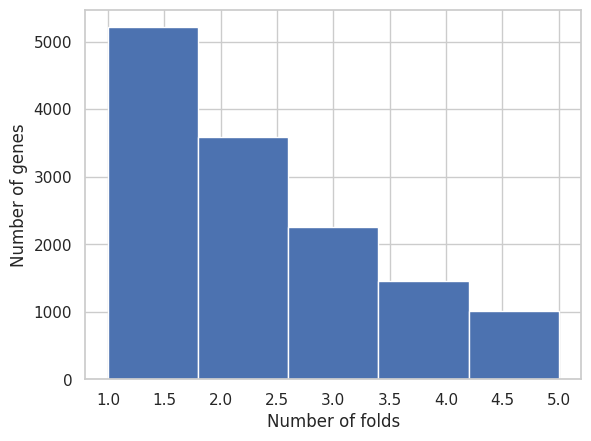

In [198]:
import matplotlib.pyplot as plt

counts = list(gene_counter.values())
plt.hist(counts, bins=len(gene_sets))
plt.xlabel("Number of folds")
plt.ylabel("Number of genes")
plt.show()

In [199]:
num_folds = len(gene_sets)

stable_genes = [g for g, c in gene_counter.items() if c >= num_folds - 1]

In [200]:
gene_score = {
    g: count / len(gene_sets)
    for g, count in gene_counter.items()
}

In [202]:
gene_score

{'ASTN1': 0.2,
 'CCDC17': 1.0,
 'CDC42EP5': 0.4,
 'CLDN8': 0.2,
 'AC104667.3': 1.0,
 'IDO1': 0.8,
 'AK3': 0.4,
 'C8orf88': 1.0,
 'PSMD14': 0.2,
 'SH2D6': 0.8,
 'SNX24': 0.8,
 'GLIPR2': 0.4,
 'SMYD2': 0.4,
 'PCDHGA10': 0.8,
 'MYLPF': 0.8,
 'TCP10L': 0.8,
 'COG8': 1.0,
 'SH3RF3': 0.2,
 'IL1B': 0.4,
 'BTAF1': 0.2,
 'CCDC74B': 1.0,
 'C2orf27A': 0.8,
 'CHSY1': 0.8,
 'SPESP1': 1.0,
 'UGT2B28': 0.8,
 'TOGARAM2': 1.0,
 'PLP1': 0.2,
 'PHTF2': 0.6,
 'ZNF730': 1.0,
 'IQGAP1': 0.6,
 'SUV39H2': 0.8,
 'SLC16A8': 0.6,
 'MS4A6E': 1.0,
 'NUDT4': 0.2,
 'GABRD': 0.6,
 'SELENOI': 0.8,
 'CCDC106': 0.4,
 'KLHL41': 0.6,
 'NSF': 0.4,
 'DOCK1': 0.6,
 'SIX2': 0.8,
 'SPRY1': 0.2,
 'TIGD7': 0.4,
 'SP4': 0.6,
 'ZNF41': 0.4,
 'LRRK1': 0.2,
 'C15orf32': 0.8,
 'TOMM7': 0.2,
 'LUC7L2': 0.6,
 'RESF1': 0.8,
 'S100A7A': 0.2,
 'SVOPL': 1.0,
 'MPZL3': 0.8,
 'C6orf141': 0.8,
 'SLC5A6': 0.4,
 'RPS25': 0.4,
 'DNM3': 0.4,
 'H2AC18': 1.0,
 'ARPC1B': 0.2,
 'OR10H5': 1.0,
 'SLC41A1': 0.4,
 'RPS14': 0.4,
 'RPGRIP1': 1.0,
 'TASL': 